# Improved Fraud Detection Project - Separated Models + Backend Saving

This notebook trains and compares several fraud detection models on the Kaggle `kartik2112/fraud-detection` dataset.

Main additions in this version:

- Each model runs in its own separate cell.
- Google Drive folders are created automatically.
- Every trained model is saved with its weights/parameters.
- Preprocessing artifacts are saved for backend use.
- A backend-ready configuration file is created.
- Extra comparison methods were added: threshold analysis, top-k fraud capture, business false-alarm comparison, feature importance, training time, and inference time.

Important backend idea: saving the model alone is not enough. The backend must also load the encoder, feature columns, medians, and threshold, then apply the exact same feature engineering before prediction.

## 1. Install and Import Libraries

In [ ]:
!pip install -q kagglehub xgboost lightgbm catboost imbalanced-learn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 24.7 MB/s eta 0:00:00


In [ ]:
import os
import json
import time
import joblib
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
LABELS = ["Legitimate", "Fraud"]

## 1.1 Create Google Drive Project Folders

The notebook creates a clean project structure in Google Drive. If Drive is not available, it saves locally instead.

In [ ]:
# Mount Google Drive only when running inside Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive'
except Exception:
    print('Google Drive was not mounted. Using local ./Fraud_Detection_Project folder instead.')
    DRIVE_ROOT = '.'

PROJECT_NAME = 'Fraud_Detection_Project'
PROJECT_DIR = os.path.join(DRIVE_ROOT, PROJECT_NAME)
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
PREPROCESSING_DIR = os.path.join(PROJECT_DIR, 'preprocessing')
REPORTS_DIR = os.path.join(PROJECT_DIR, 'reports')
FIGURES_DIR = os.path.join(PROJECT_DIR, 'figures')
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, 'predictions')
BACKEND_DIR = os.path.join(PROJECT_DIR, 'backend_ready')

for folder in [PROJECT_DIR, MODELS_DIR, PREPROCESSING_DIR, REPORTS_DIR, FIGURES_DIR, PREDICTIONS_DIR, BACKEND_DIR]:
    os.makedirs(folder, exist_ok=True)

print('Project folders created:')
for folder in [PROJECT_DIR, MODELS_DIR, PREPROCESSING_DIR, REPORTS_DIR, FIGURES_DIR, PREDICTIONS_DIR, BACKEND_DIR]:
    print(folder)

Mounted at /content/drive
Project folders created:
/content/drive/MyDrive/Fraud_Detection_Project
/content/drive/MyDrive/Fraud_Detection_Project/models
/content/drive/MyDrive/Fraud_Detection_Project/preprocessing
/content/drive/MyDrive/Fraud_Detection_Project/reports
/content/drive/MyDrive/Fraud_Detection_Project/figures
/content/drive/MyDrive/Fraud_Detection_Project/predictions
/content/drive/MyDrive/Fraud_Detection_Project/backend_ready


## 2. Load Dataset

In [ ]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

train_path = os.path.join(path, "fraudTrain.csv")
test_path = os.path.join(path, "fraudTest.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Fraud rate in train: {:.4f}%".format(train_df["is_fraud"].mean() * 100))
print("Fraud rate in test:  {:.4f}%".format(test_df["is_fraud"].mean() * 100))

train_df.head()

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Train shape: (1296675, 23)
Test shape: (555719, 23)
Fraud rate in train: 0.5789%
Fraud rate in test:  0.3860%


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 3. Feature Engineering and Preprocessing

The encoder is fitted only on the training set and then applied to the test set. This avoids data leakage.

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in kilometers between two latitude/longitude points."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c


def add_features(df):
    df = df.copy()

    # Remove index-like columns if they exist
    df = df.drop(columns=[col for col in ["Unnamed: 0"] if col in df.columns], errors="ignore")

    # Time features
    if "trans_date_trans_time" in df.columns:
        trans_time = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
        df["hour"] = trans_time.dt.hour
        df["day_of_week"] = trans_time.dt.dayofweek
        df["month"] = trans_time.dt.month
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    else:
        trans_time = None

    # Age feature
    if "dob" in df.columns:
        dob = pd.to_datetime(df["dob"], errors="coerce")
        if trans_time is not None:
            df["age"] = trans_time.dt.year - dob.dt.year
        else:
            df["age"] = 2020 - dob.dt.year

    # Distance between customer and merchant
    required_distance_cols = {"lat", "long", "merch_lat", "merch_long"}
    if required_distance_cols.issubset(df.columns):
        df["distance_km"] = haversine_distance(
            df["lat"], df["long"], df["merch_lat"], df["merch_long"]
        )

    # Drop columns that are identifiers or text-heavy personal information
    drop_cols = [
        "trans_date_trans_time", "cc_num", "first", "last", "street", "city", "state",
        "zip", "trans_num", "unix_time", "dob"
    ]
    df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors="ignore")

    return df


train_fe = add_features(train_df)
test_fe = add_features(test_df)

X_train_raw = train_fe.drop("is_fraud", axis=1)
y_train = train_fe["is_fraud"].astype(int)

X_test_raw = test_fe.drop("is_fraud", axis=1)
y_test = test_fe["is_fraud"].astype(int)

cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [col for col in X_train_raw.columns if col not in cat_cols]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

if cat_cols:
    X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
    X_test[cat_cols] = encoder.transform(X_test[cat_cols].astype(str))

# Make sure both train and test have the same columns in the same order
X_test = X_test[X_train.columns]

# Fill missing values using train medians only
medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

print("Number of features:", X_train.shape[1])
print("Categorical columns encoded:", cat_cols)
print("Final feature columns:")
print(X_train.columns.tolist())

Number of features: 16
Categorical columns encoded: ['merchant', 'category', 'gender', 'job']
Final feature columns:
['merchant', 'category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month', 'is_weekend', 'age', 'distance_km']


## 3.1 Save Preprocessing Objects for Backend Use

These files are essential for the backend. The backend must apply the same encoder, same columns, and same missing-value strategy before calling the model.

In [ ]:
preprocessing_artifacts = {
    'encoder': encoder,
    'medians': medians,
    'feature_columns': X_train.columns.tolist(),
    'categorical_columns': cat_cols,
    'numeric_columns': num_cols,
    'label_names': LABELS,
}

preprocessing_path = os.path.join(PREPROCESSING_DIR, 'preprocessing_artifacts.joblib')
joblib.dump(preprocessing_artifacts, preprocessing_path)

feature_columns_path = os.path.join(BACKEND_DIR, 'feature_columns.json')
with open(feature_columns_path, 'w') as f:
    json.dump(X_train.columns.tolist(), f, indent=4)

print('Saved preprocessing artifacts:', preprocessing_path)
print('Saved backend feature columns:', feature_columns_path)

Saved preprocessing artifacts: /content/drive/MyDrive/Fraud_Detection_Project/preprocessing/preprocessing_artifacts.joblib
Saved backend feature columns: /content/drive/MyDrive/Fraud_Detection_Project/backend_ready/feature_columns.json


## 4. Optional Sampling for Faster Experiments

Set `USE_SMALL_SAMPLE = True` only if training is too slow. For final results, keep it `False`.

In [ ]:
USE_SMALL_SAMPLE = False
SAMPLE_SIZE = 250_000

if USE_SMALL_SAMPLE and len(X_train) > SAMPLE_SIZE:
    sample_idx = X_train.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).index
    X_train_model = X_train.loc[sample_idx]
    y_train_model = y_train.loc[sample_idx]
else:
    X_train_model = X_train
    y_train_model = y_train

print("Training size used:", X_train_model.shape)
print("Fraud cases used:", int(y_train_model.sum()))

Training size used: (1296675, 16)
Fraud cases used: 7506


## 5. Helper Functions for Evaluation, Saving, and Comparison

In [ ]:
def clean_model_name(model_name):
    return model_name.lower().replace(' ', '_').replace('-', '_')


def save_plot(fig, filename):
    path = os.path.join(FIGURES_DIR, filename)
    fig.savefig(path, bbox_inches='tight', dpi=150)
    print('Saved plot:', path)
    return path


def get_scores(y_true, y_pred, y_prob=None):
    scores = {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
    }

    if y_prob is not None:
        scores['ROC-AUC'] = roc_auc_score(y_true, y_prob)
        scores['PR-AUC'] = average_precision_score(y_true, y_prob)
    else:
        scores['ROC-AUC'] = np.nan
        scores['PR-AUC'] = np.nan

    return scores


def plot_confusion_matrix_for_model(y_true, y_pred, model_name, normalize=None, save=True):
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(cmap='Blues', values_format='.2f' if normalize else 'd')
    title = f'Confusion Matrix - {model_name}'
    if normalize:
        title += f' ({normalize})'
    plt.title(title)
    plt.grid(False)

    fig = plt.gcf()
    if save:
        suffix = f'_normalized_{normalize}' if normalize else ''
        save_plot(fig, f'{clean_model_name(model_name)}_confusion_matrix{suffix}.png')
    plt.show()

    if normalize is None:
        tn, fp, fn, tp = cm.ravel()
        print(f'{model_name} confusion matrix values:')
        print('TN:', tn, 'FP:', fp)
        print('FN:', fn, 'TP:', tp)


def save_model_artifacts(model_name, model, y_pred, y_prob, scores, threshold=0.5,
                         training_time=None, inference_time=None):
    safe_name = clean_model_name(model_name)

    model_path = os.path.join(MODELS_DIR, f'{safe_name}.joblib')
    joblib.dump(model, model_path)

    prediction_path = os.path.join(PREDICTIONS_DIR, f'{safe_name}_predictions.csv')
    pred_df = pd.DataFrame({
        'y_true': y_test.values,
        'y_pred': y_pred,
        'y_score': y_prob if y_prob is not None else np.nan,
    })
    pred_df.to_csv(prediction_path, index=False)

    metrics_path = os.path.join(REPORTS_DIR, f'{safe_name}_metrics.json')
    metrics_payload = {
        'model_name': model_name,
        'threshold': float(threshold),
        'saved_at': datetime.now().isoformat(),
        'training_time_seconds': None if training_time is None else float(training_time),
        'inference_time_seconds': None if inference_time is None else float(inference_time),
        'scores': {k: (None if pd.isna(v) else float(v)) for k, v in scores.items()},
        'feature_columns': X_train.columns.tolist(),
        'categorical_columns': cat_cols,
    }
    with open(metrics_path, 'w') as f:
        json.dump(metrics_payload, f, indent=4)

    print('Saved model:', model_path)
    print('Saved predictions:', prediction_path)
    print('Saved metrics:', metrics_path)
    return model_path


def evaluate_model(model_name, model, X_train_data, y_train_data, X_test_data, y_test_data, threshold=0.5, save=True):
    print('=' * 70)
    print(f'Training: {model_name}')
    print('=' * 70)

    train_start = time.time()
    model.fit(X_train_data, y_train_data)
    training_time = time.time() - train_start

    infer_start = time.time()
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_prob = None
        y_pred = model.predict(X_test_data)
    inference_time = time.time() - infer_start

    print(f'Training time: {training_time:.2f} seconds')
    print(f'Inference time on test set: {inference_time:.2f} seconds')
    print(f'Classification Report - {model_name}')
    print(classification_report(y_test_data, y_pred, target_names=LABELS, zero_division=0))

    plot_confusion_matrix_for_model(y_test_data, y_pred, model_name)
    plot_confusion_matrix_for_model(y_test_data, y_pred, model_name, normalize='true')

    scores = get_scores(y_test_data, y_pred, y_prob)

    if save:
        save_model_artifacts(
            model_name, model, y_pred, y_prob, scores,
            threshold=threshold,
            training_time=training_time,
            inference_time=inference_time,
        )

    return {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'scores': scores,
        'threshold': threshold,
        'training_time_seconds': training_time,
        'inference_time_seconds': inference_time,
    }

## 6. Define Model Settings

The dataset is highly imbalanced, so supervised models use class weights or fraud weighting.

In [ ]:
pos_weight = (y_train_model == 0).sum() / max((y_train_model == 1).sum(), 1)
print('scale_pos_weight:', pos_weight)

results = {}

scale_pos_weight: 171.75179856115108


### 6.1 Train and Save Random Forest

Training: Random Forest
Training time: 147.87 seconds
Inference time on test set: 1.51 seconds
Classification Report - Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.94      0.72      0.82      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.86      0.91    555719
weighted avg       1.00      1.00      1.00    555719

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/random_forest_confusion_matrix.png


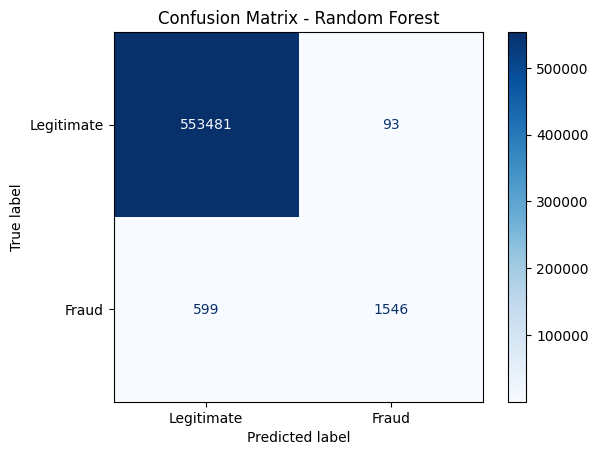

Random Forest confusion matrix values:
TN: 553481 FP: 93
FN: 599 TP: 1546
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/random_forest_confusion_matrix_normalized_true.png


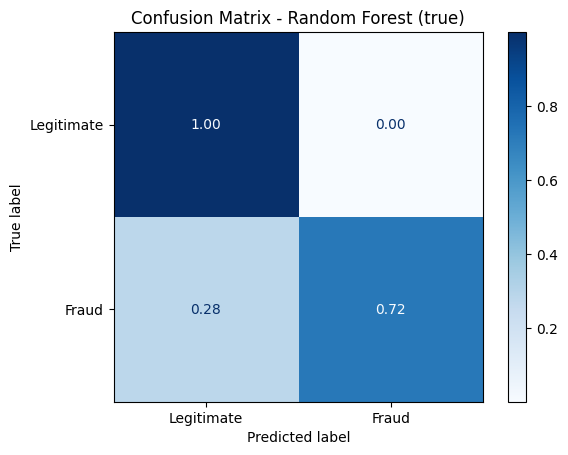

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/models/random_forest.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/predictions/random_forest_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/reports/random_forest_metrics.json


In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

results['Random Forest'] = evaluate_model(
    'Random Forest',
    random_forest_model,
    X_train_model,
    y_train_model,
    X_test,
    y_test,
    threshold=0.5,
)

### 6.2 Train and Save XGBoost

Training: XGBoost
Training time: 8.65 seconds
Inference time on test set: 0.67 seconds
Classification Report - XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.31      0.94      0.47      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.96      0.73    555719
weighted avg       1.00      0.99      0.99    555719

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/xgboost_confusion_matrix.png


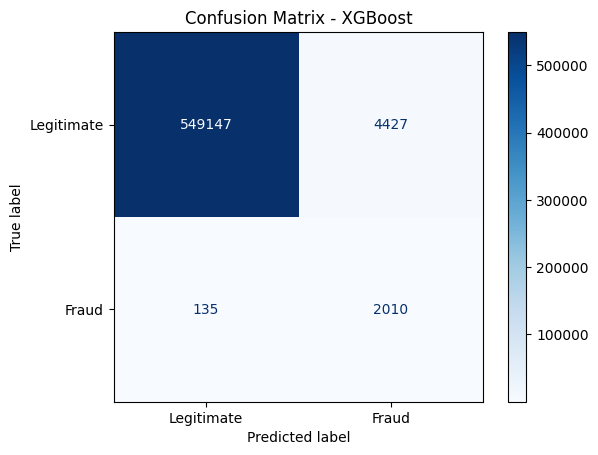

XGBoost confusion matrix values:
TN: 549147 FP: 4427
FN: 135 TP: 2010
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/xgboost_confusion_matrix_normalized_true.png


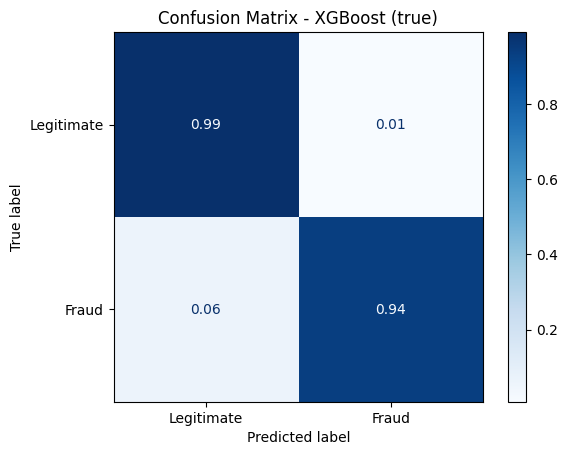

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/models/xgboost.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/predictions/xgboost_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/reports/xgboost_metrics.json
Saved native XGBoost model: /content/drive/MyDrive/Fraud_Detection_Project/models/xgboost_model.json


In [ ]:
xgboost_model = XGBClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

results['XGBoost'] = evaluate_model(
    'XGBoost',
    xgboost_model,
    X_train_model,
    y_train_model,
    X_test,
    y_test,
    threshold=0.5,
)

# Optional native XGBoost format, useful outside Python/joblib environments
xgboost_native_path = os.path.join(MODELS_DIR, 'xgboost_model.json')
xgboost_model.save_model(xgboost_native_path)
print('Saved native XGBoost model:', xgboost_native_path)

### 6.3 Train and Save LightGBM

Training: LightGBM
Training time: 9.59 seconds
Inference time on test set: 1.75 seconds
Classification Report - LightGBM
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.46      0.90      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.95      0.80    555719
weighted avg       1.00      1.00      1.00    555719

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/lightgbm_confusion_matrix.png


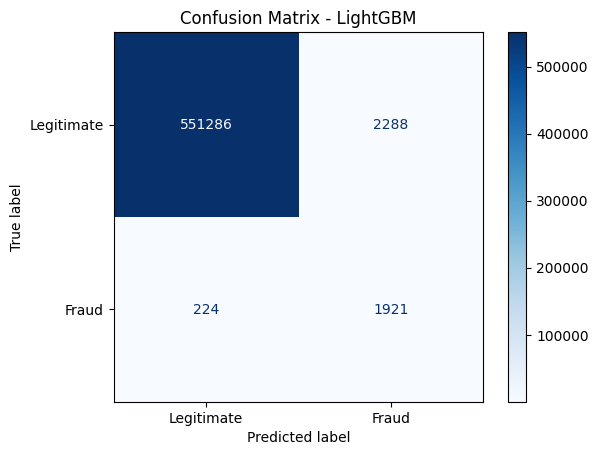

LightGBM confusion matrix values:
TN: 551286 FP: 2288
FN: 224 TP: 1921
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/lightgbm_confusion_matrix_normalized_true.png


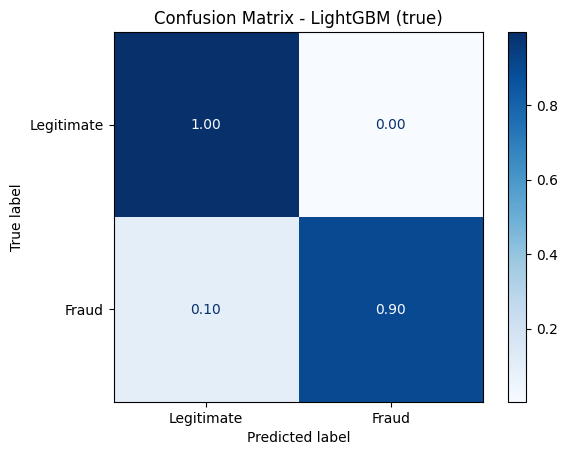

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/models/lightgbm.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/predictions/lightgbm_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/reports/lightgbm_metrics.json


In [ ]:
lightgbm_model = LGBMClassifier(
    n_estimators=350,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

results['LightGBM'] = evaluate_model(
    'LightGBM',
    lightgbm_model,
    X_train_model,
    y_train_model,
    X_test,
    y_test,
    threshold=0.5,
)

### 6.4 Train and Save CatBoost

Training: CatBoost
Training time: 73.98 seconds
Inference time on test set: 0.07 seconds
Classification Report - CatBoost
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.30      0.95      0.45      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.97      0.72    555719
weighted avg       1.00      0.99      0.99    555719

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/catboost_confusion_matrix.png


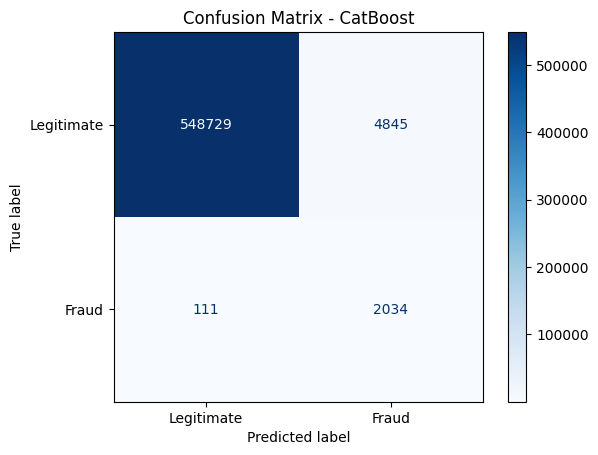

CatBoost confusion matrix values:
TN: 548729 FP: 4845
FN: 111 TP: 2034
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/catboost_confusion_matrix_normalized_true.png


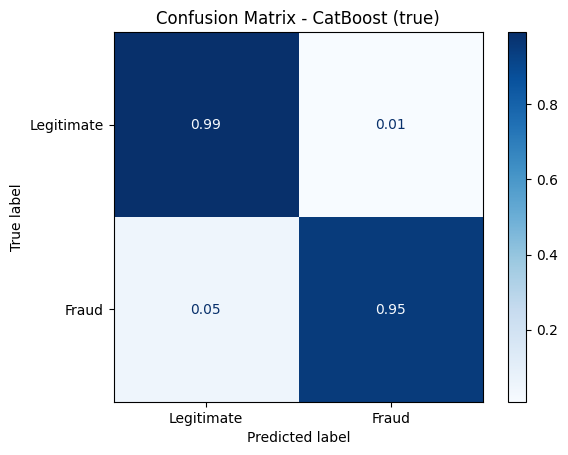

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/models/catboost.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/predictions/catboost_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/reports/catboost_metrics.json
Saved native CatBoost model: /content/drive/MyDrive/Fraud_Detection_Project/models/catboost_model.cbm


In [ ]:
catboost_model = CatBoostClassifier(
    iterations=350,
    learning_rate=0.05,
    depth=8,
    auto_class_weights='Balanced',
    loss_function='Logloss',
    eval_metric='PRAUC',
    verbose=0,
    random_state=RANDOM_STATE,
)

results['CatBoost'] = evaluate_model(
    'CatBoost',
    catboost_model,
    X_train_model,
    y_train_model,
    X_test,
    y_test,
    threshold=0.5,
)

# Optional native CatBoost format
catboost_native_path = os.path.join(MODELS_DIR, 'catboost_model.cbm')
catboost_model.save_model(catboost_native_path)
print('Saved native CatBoost model:', catboost_native_path)

### 7. Train and Save Isolation Forest

Training: Isolation Forest
Training time: 17.27 seconds
Inference time on test set: 13.45 seconds
Classification Report - Isolation Forest
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.05      0.07      0.06      2145

    accuracy                           0.99    555719
   macro avg       0.52      0.53      0.53    555719
weighted avg       0.99      0.99      0.99    555719

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/isolation_forest_confusion_matrix.png


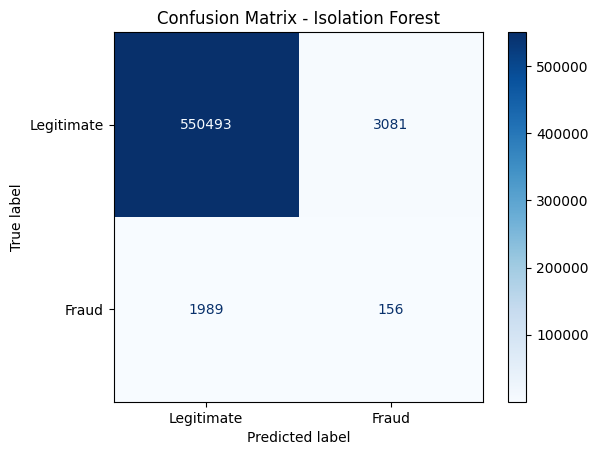

Isolation Forest confusion matrix values:
TN: 550493 FP: 3081
FN: 1989 TP: 156
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/isolation_forest_confusion_matrix_normalized_true.png


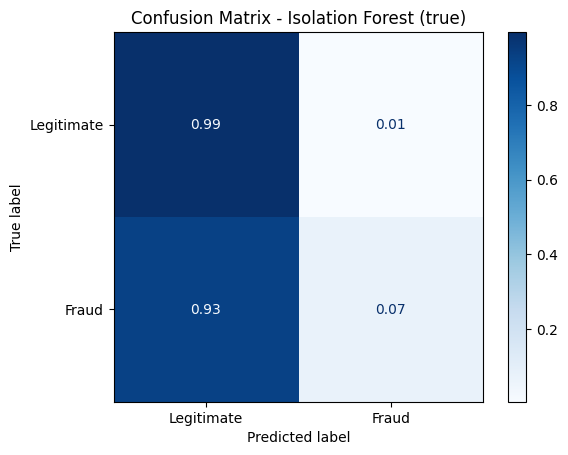

Saved model: /content/drive/MyDrive/Fraud_Detection_Project/models/isolation_forest.joblib
Saved predictions: /content/drive/MyDrive/Fraud_Detection_Project/predictions/isolation_forest_predictions.csv
Saved metrics: /content/drive/MyDrive/Fraud_Detection_Project/reports/isolation_forest_metrics.json


In [ ]:
iso_model = IsolationForest(
    n_estimators=250,
    contamination=float(y_train_model.mean()),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print('=' * 70)
print('Training: Isolation Forest')
print('=' * 70)

train_start = time.time()
iso_model.fit(X_train_model)
training_time = time.time() - train_start

infer_start = time.time()
# IsolationForest output: -1 means anomaly, 1 means normal
iso_raw_pred = iso_model.predict(X_test)
y_pred_iso = np.where(iso_raw_pred == -1, 1, 0)

# A higher score should mean more likely fraud, so we negate decision_function
iso_scores = -iso_model.decision_function(X_test)
inference_time = time.time() - infer_start

print(f'Training time: {training_time:.2f} seconds')
print(f'Inference time on test set: {inference_time:.2f} seconds')
print('Classification Report - Isolation Forest')
print(classification_report(y_test, y_pred_iso, target_names=LABELS, zero_division=0))
plot_confusion_matrix_for_model(y_test, y_pred_iso, 'Isolation Forest')
plot_confusion_matrix_for_model(y_test, y_pred_iso, 'Isolation Forest', normalize='true')

iso_scores_dict = get_scores(y_test, y_pred_iso, iso_scores)
save_model_artifacts(
    'Isolation Forest', iso_model, y_pred_iso, iso_scores, iso_scores_dict,
    threshold=float(y_train_model.mean()),
    training_time=training_time,
    inference_time=inference_time,
)

results['Isolation Forest'] = {
    'model': iso_model,
    'y_pred': y_pred_iso,
    'y_prob': iso_scores,
    'scores': iso_scores_dict,
    'threshold': float(y_train_model.mean()),
    'training_time_seconds': training_time,
    'inference_time_seconds': inference_time,
}

## 8. Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame({
    model_name: result['scores']
    for model_name, result in results.items()
}).T

comparison_df['Training Time (sec)'] = [results[m]['training_time_seconds'] for m in comparison_df.index]
comparison_df['Inference Time (sec)'] = [results[m]['inference_time_seconds'] for m in comparison_df.index]
comparison_df['Threshold'] = [results[m]['threshold'] for m in comparison_df.index]

comparison_df = comparison_df.sort_values(by='PR-AUC', ascending=False)
comparison_path = os.path.join(REPORTS_DIR, 'model_comparison_metrics.csv')
comparison_df.to_csv(comparison_path)
print('Saved comparison table:', comparison_path)
comparison_df

Saved comparison table: /content/drive/MyDrive/Fraud_Detection_Project/reports/model_comparison_metrics.csv


,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,Training Time (sec),Inference Time (sec),Threshold
LightGBM,0.456403,0.895571,0.604658,0.945719,0.996655,0.871377,9.588442,1.749886,0.500000
XGBoost,0.312257,0.937063,0.468422,0.964533,0.997078,0.871183,8.646127,0.666796,0.500000
CatBoost,0.295683,0.948252,0.450798,0.969750,0.997062,0.869363,73.983789,0.070279,0.500000
Random Forest,0.943258,0.720746,0.817125,0.860289,0.986724,0.867069,147.873977,1.512715,0.500000
Isolation Forest,0.048193,0.072727,0.057971,0.533581,0.807101,0.029420,17.266265,13.451467,0.005789


## 9. Bar Charts for Model Comparison

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/model_comparison_pr_auc.png


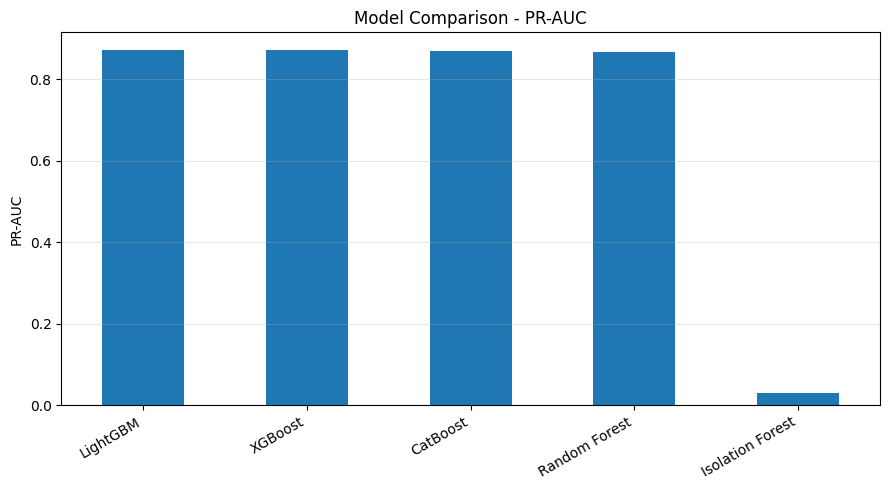

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/model_comparison_roc_auc.png


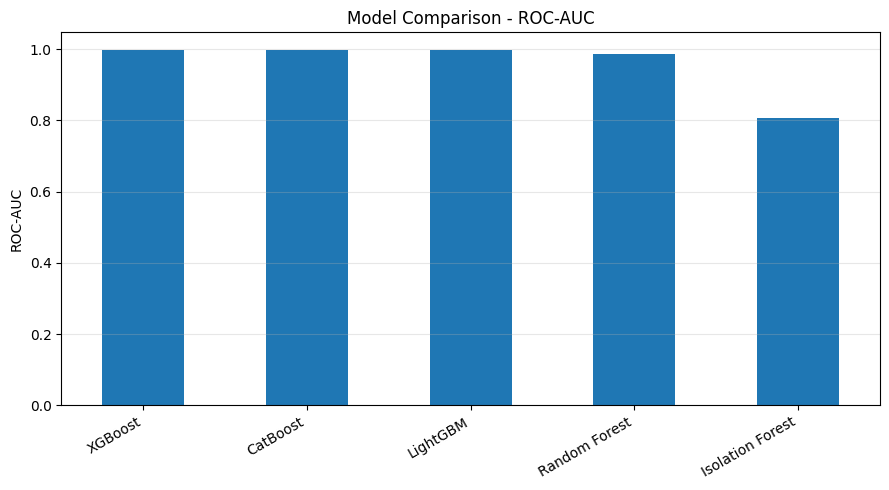

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/model_comparison_recall.png


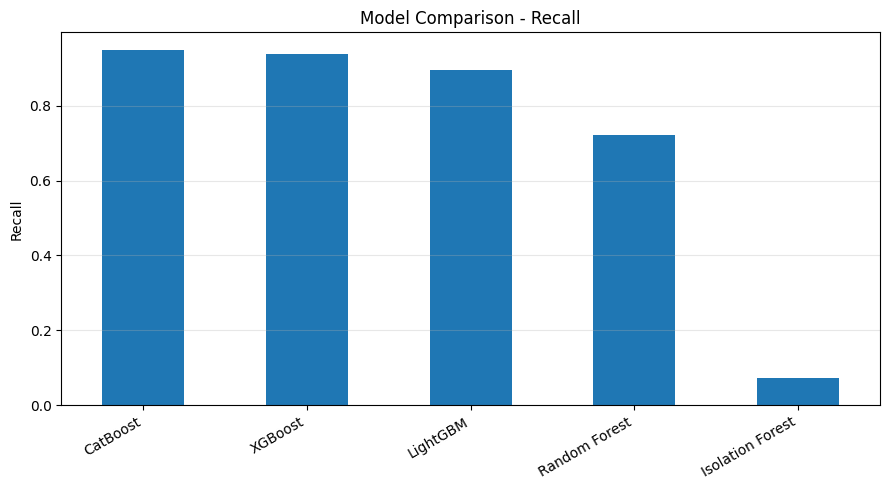

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/model_comparison_f1.png


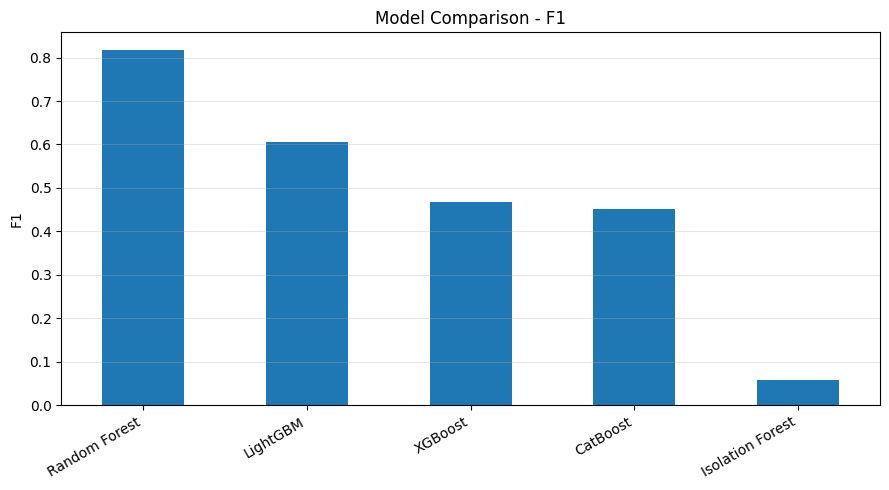

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/model_comparison_balanced_accuracy.png


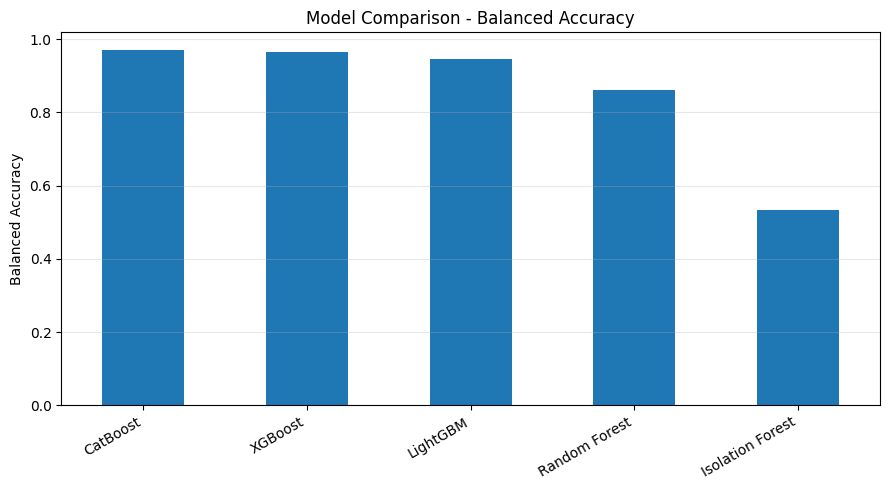

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/model_comparison_training_time_sec.png


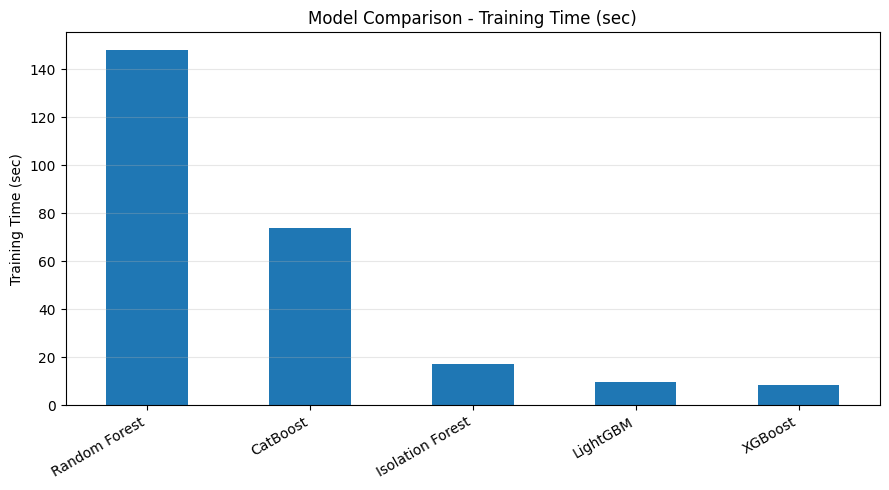

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/model_comparison_inference_time_sec.png


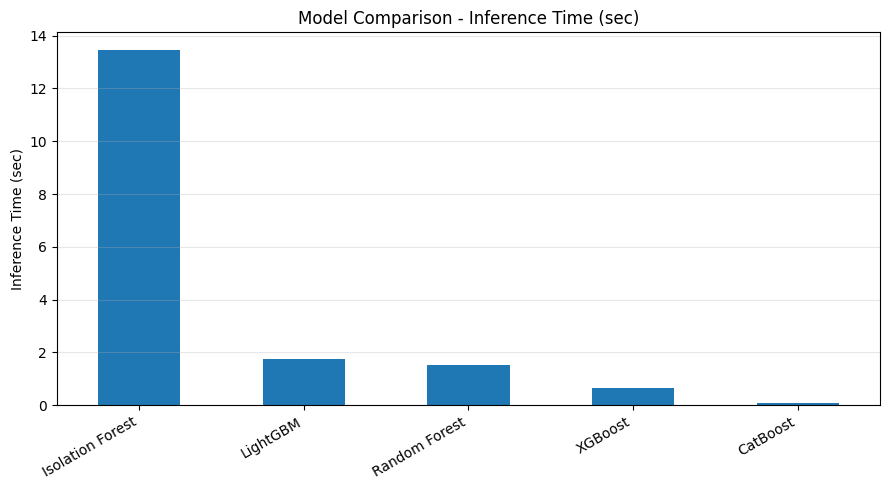

In [ ]:
metrics_to_plot = ['PR-AUC', 'ROC-AUC', 'Recall', 'F1', 'Balanced Accuracy', 'Training Time (sec)', 'Inference Time (sec)']

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 5))
    comparison_df[metric].sort_values(ascending=False).plot(kind='bar')
    plt.title(f'Model Comparison - {metric}')
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), f'model_comparison_{metric.lower().replace(" ", "_").replace("-", "_").replace("(", "").replace(")", "")}.png')
    plt.show()

## 10. ROC and Precision-Recall Curves

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/roc_curve_comparison.png


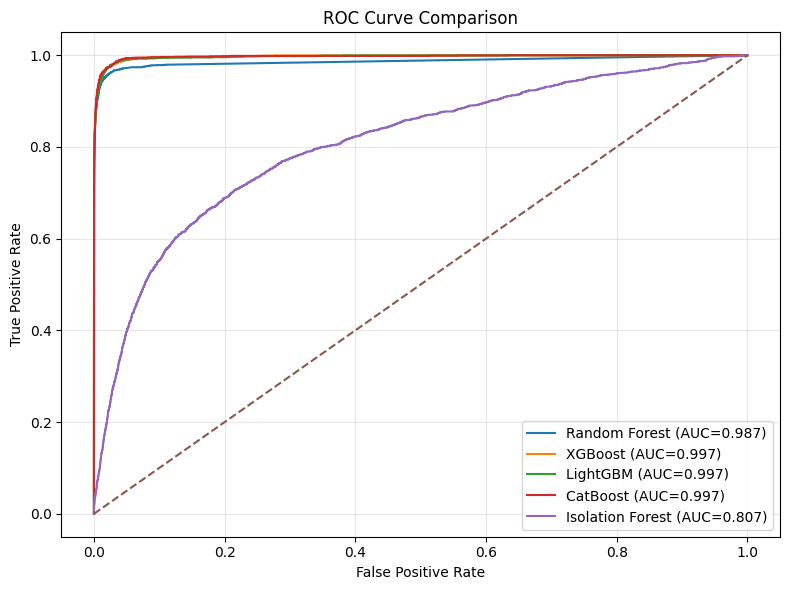

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/precision_recall_curve_comparison.png


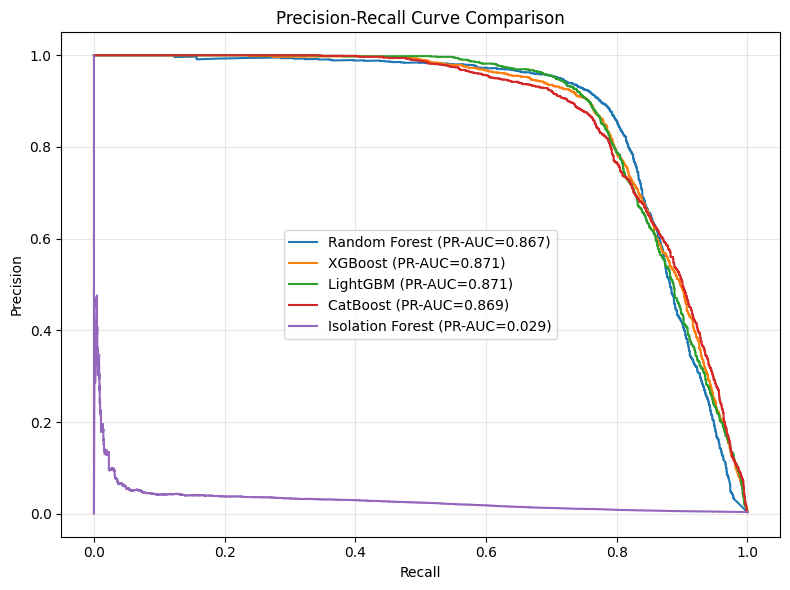

In [ ]:
plt.figure(figsize=(8, 6))
for model_name, result in results.items():
    y_prob = result['y_prob']
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc_score(y_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot(plt.gcf(), 'roc_curve_comparison.png')
plt.show()

plt.figure(figsize=(8, 6))
for model_name, result in results.items():
    y_prob = result['y_prob']
    if y_prob is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        plt.plot(recall, precision, label=f'{model_name} (PR-AUC={pr_auc:.3f})')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot(plt.gcf(), 'precision_recall_curve_comparison.png')
plt.show()

## 11. Additional Comparison Methods

These comparisons are useful for a fraud-detection report and for backend/business decisions. They show not only which model is statistically better, but also how many false alarms the model creates and how many fraud cases it catches.

In [ ]:
# Business-style comparison: frauds caught, missed frauds, and false alarms
business_rows = []
for model_name, result in results.items():
    cm = confusion_matrix(y_test, result['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    business_rows.append({
        'Model': model_name,
        'Frauds Caught (TP)': tp,
        'Frauds Missed (FN)': fn,
        'False Alarms (FP)': fp,
        'Correct Legitimate (TN)': tn,
        'Fraud Recall': tp / max(tp + fn, 1),
        'False Alarm Rate': fp / max(fp + tn, 1),
    })

business_df = pd.DataFrame(business_rows).sort_values(by='Fraud Recall', ascending=False)
business_path = os.path.join(REPORTS_DIR, 'business_comparison_false_alarms.csv')
business_df.to_csv(business_path, index=False)
print('Saved business comparison:', business_path)
business_df

Saved business comparison: /content/drive/MyDrive/Fraud_Detection_Project/reports/business_comparison_false_alarms.csv


,Model,Frauds Caught (TP),Frauds Missed (FN),False Alarms (FP),Correct Legitimate (TN),Fraud Recall,False Alarm Rate
3,CatBoost,2034,111,4845,548729,0.948252,0.008752
1,XGBoost,2010,135,4427,549147,0.937063,0.007997
2,LightGBM,1921,224,2288,551286,0.895571,0.004133
0,Random Forest,1546,599,93,553481,0.720746,0.000168
4,Isolation Forest,156,1989,3081,550493,0.072727,0.005566


In [ ]:
# Top-K fraud capture: if the backend reviews only the most suspicious transactions,
# how many fraud cases are captured?
top_k_values = [100, 500, 1000, 5000, 10000]
topk_rows = []

for model_name, result in results.items():
    y_prob = result['y_prob']
    if y_prob is None:
        continue

    ranked_df = pd.DataFrame({'y_true': y_test.values, 'score': y_prob}).sort_values('score', ascending=False)
    total_frauds = ranked_df['y_true'].sum()

    for k in top_k_values:
        k = min(k, len(ranked_df))
        frauds_found = ranked_df.head(k)['y_true'].sum()
        topk_rows.append({
            'Model': model_name,
            'Top K Transactions Reviewed': k,
            'Frauds Found': int(frauds_found),
            'Fraud Capture Rate': frauds_found / max(total_frauds, 1),
            'Precision@K': frauds_found / max(k, 1),
        })

topk_df = pd.DataFrame(topk_rows)
topk_path = os.path.join(REPORTS_DIR, 'top_k_fraud_capture.csv')
topk_df.to_csv(topk_path, index=False)
print('Saved top-k comparison:', topk_path)
topk_df

Saved top-k comparison: /content/drive/MyDrive/Fraud_Detection_Project/reports/top_k_fraud_capture.csv


,Model,Top K Transactions Reviewed,Frauds Found,Fraud Capture Rate,Precision@K
0,Random Forest,100,100,0.046620,1.0000
1,Random Forest,500,497,0.231702,0.9940
2,Random Forest,1000,985,0.459207,0.9850
3,Random Forest,5000,1943,0.905828,0.3886
4,Random Forest,10000,2034,0.948252,0.2034
5,XGBoost,100,100,0.046620,1.0000
6,XGBoost,500,500,0.233100,1.0000
7,XGBoost,1000,996,0.464336,0.9960
8,XGBoost,5000,1974,0.920280,0.3948
9,XGBoost,10000,2060,0.960373,0.2060


In [ ]:
# Threshold curve for every scored model
threshold_grid = np.linspace(0.01, 0.99, 99)
threshold_curve_rows = []

for model_name, result in results.items():
    y_prob = result['y_prob']
    if y_prob is None:
        continue

    for threshold in threshold_grid:
        y_pred_t = (y_prob >= threshold).astype(int)
        threshold_curve_rows.append({
            'Model': model_name,
            'Threshold': threshold,
            'Precision': precision_score(y_test, y_pred_t, zero_division=0),
            'Recall': recall_score(y_test, y_pred_t, zero_division=0),
            'F1': f1_score(y_test, y_pred_t, zero_division=0),
            'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_t),
        })

threshold_curves_df = pd.DataFrame(threshold_curve_rows)
threshold_curves_path = os.path.join(REPORTS_DIR, 'all_models_threshold_curves.csv')
threshold_curves_df.to_csv(threshold_curves_path, index=False)
print('Saved threshold curves:', threshold_curves_path)
threshold_curves_df.head()

Saved threshold curves: /content/drive/MyDrive/Fraud_Detection_Project/reports/all_models_threshold_curves.csv


,Model,Threshold,Precision,Recall,F1,Balanced Accuracy
0,Random Forest,0.01,0.117190,0.963636,0.208967,0.967754
1,Random Forest,0.02,0.216583,0.944988,0.352399,0.965872
2,Random Forest,0.03,0.270044,0.934266,0.418984,0.962240
3,Random Forest,0.04,0.336126,0.916550,0.491869,0.954768
4,Random Forest,0.05,0.375265,0.908159,0.531080,0.951150


Saved feature importance: /content/drive/MyDrive/Fraud_Detection_Project/reports/random_forest_feature_importance.csv
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/random_forest_feature_importance.png


<Figure size 900x600 with 0 Axes>

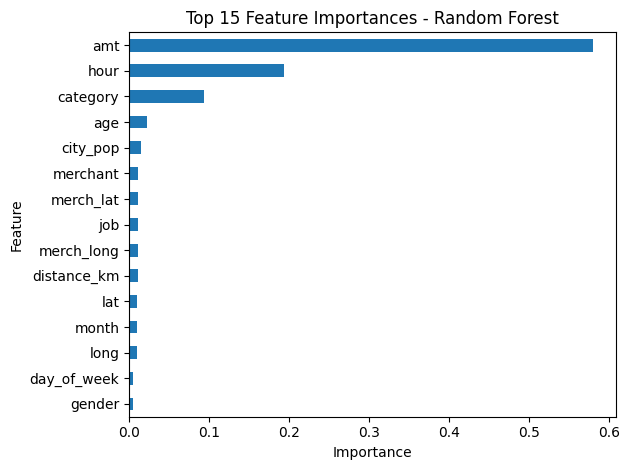

Saved feature importance: /content/drive/MyDrive/Fraud_Detection_Project/reports/xgboost_feature_importance.csv
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/xgboost_feature_importance.png


<Figure size 900x600 with 0 Axes>

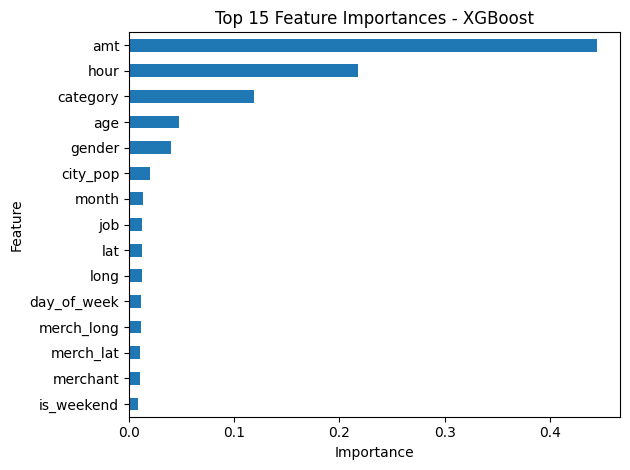

Saved feature importance: /content/drive/MyDrive/Fraud_Detection_Project/reports/lightgbm_feature_importance.csv
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/lightgbm_feature_importance.png


<Figure size 900x600 with 0 Axes>

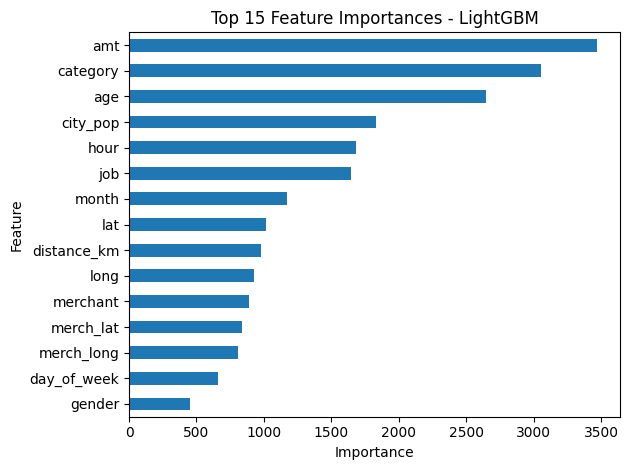

Saved feature importance: /content/drive/MyDrive/Fraud_Detection_Project/reports/catboost_feature_importance.csv
Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/catboost_feature_importance.png


<Figure size 900x600 with 0 Axes>

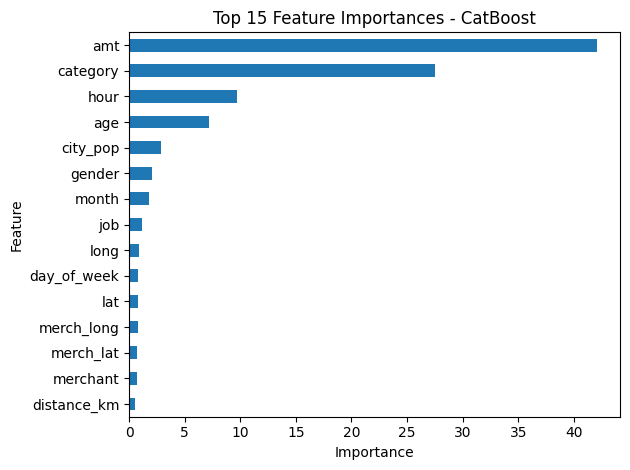

In [ ]:
# Feature importance comparison for tree-based models
for model_name, result in results.items():
    model = result['model']
    if hasattr(model, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.feature_importances_,
        }).sort_values(by='Importance', ascending=False)

        importance_path = os.path.join(REPORTS_DIR, f'{clean_model_name(model_name)}_feature_importance.csv')
        importance_df.to_csv(importance_path, index=False)
        print('Saved feature importance:', importance_path)

        plt.figure(figsize=(9, 6))
        importance_df.head(15).sort_values('Importance').plot(
            x='Feature', y='Importance', kind='barh', legend=False
        )
        plt.title(f'Top 15 Feature Importances - {model_name}')
        plt.xlabel('Importance')
        plt.tight_layout()
        save_plot(plt.gcf(), f'{clean_model_name(model_name)}_feature_importance.png')
        plt.show()

## 12. Tune Threshold for the Best Model

The default threshold is `0.5`. In fraud detection, threshold tuning is important because sometimes we prefer higher fraud recall even if it creates more false alarms.

Best model by PR-AUC: LightGBM
Saved threshold tuning table: /content/drive/MyDrive/Fraud_Detection_Project/reports/lightgbm_threshold_tuning.csv


,Threshold,Precision,Recall,F1,Balanced Accuracy
0,0.01,0.074781,0.990210,0.139060,0.971369
1,0.02,0.099868,0.985082,0.181350,0.975339
2,0.03,0.117838,0.979953,0.210379,0.975764
3,0.04,0.132634,0.978089,0.233591,0.976652
4,0.05,0.145514,0.973893,0.253197,0.975867
...,...,...,...,...,...
94,0.95,0.907962,0.749650,0.821246,0.874678
95,0.96,0.922093,0.739394,0.820699,0.869576
96,0.97,0.934456,0.724476,0.816176,0.862139
97,0.98,0.952771,0.705361,0.810608,0.852613


Best threshold by F1: 0.9400000000000001
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.90      0.76      0.82      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.88      0.91    555719
weighted avg       1.00      1.00      1.00    555719

Saved plot: /content/drive/MyDrive/Fraud_Detection_Project/figures/lightgbm___tuned_threshold_confusion_matrix.png


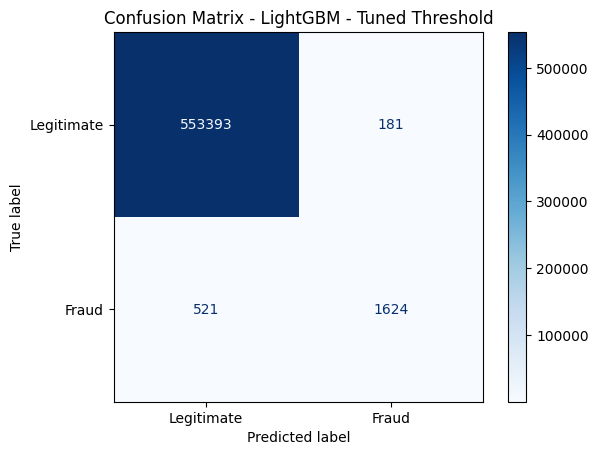

LightGBM - Tuned Threshold confusion matrix values:
TN: 553393 FP: 181
FN: 521 TP: 1624
Saved backend config: /content/drive/MyDrive/Fraud_Detection_Project/backend_ready/backend_model_config.json


In [ ]:
best_model_name = comparison_df.index[0]
best_result = results[best_model_name]
y_prob_best = best_result['y_prob']

print('Best model by PR-AUC:', best_model_name)

if y_prob_best is not None:
    thresholds = np.linspace(0.01, 0.99, 99)
    threshold_rows = []

    for threshold in thresholds:
        y_pred_t = (y_prob_best >= threshold).astype(int)
        threshold_rows.append({
            'Threshold': threshold,
            'Precision': precision_score(y_test, y_pred_t, zero_division=0),
            'Recall': recall_score(y_test, y_pred_t, zero_division=0),
            'F1': f1_score(y_test, y_pred_t, zero_division=0),
            'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_t),
        })

    threshold_df = pd.DataFrame(threshold_rows)
    threshold_path = os.path.join(REPORTS_DIR, f'{clean_model_name(best_model_name)}_threshold_tuning.csv')
    threshold_df.to_csv(threshold_path, index=False)
    print('Saved threshold tuning table:', threshold_path)
    display(threshold_df)

    best_f1_row = threshold_df.loc[threshold_df['F1'].idxmax()]
    best_threshold = float(best_f1_row['Threshold'])
    print('Best threshold by F1:', best_threshold)

    y_pred_best_threshold = (y_prob_best >= best_threshold).astype(int)
    print(classification_report(y_test, y_pred_best_threshold, target_names=LABELS, zero_division=0))
    plot_confusion_matrix_for_model(y_test, y_pred_best_threshold, f'{best_model_name} - Tuned Threshold')

    backend_config = {
        'best_model_name': best_model_name,
        'best_model_file': f'{clean_model_name(best_model_name)}.joblib',
        'best_threshold_by_f1': best_threshold,
        'preprocessing_file': 'preprocessing_artifacts.joblib',
        'feature_columns_file': 'feature_columns.json',
        'created_at': datetime.now().isoformat(),
    }

    backend_config_path = os.path.join(BACKEND_DIR, 'backend_model_config.json')
    with open(backend_config_path, 'w') as f:
        json.dump(backend_config, f, indent=4)

    print('Saved backend config:', backend_config_path)

## 13. Backend Loading Example

This cell shows how the saved model and preprocessing artifacts can later be loaded inside a backend service. The backend must create the same features in the same column order before prediction.

In [ ]:
backend_config_path = os.path.join(BACKEND_DIR, 'backend_model_config.json')

if os.path.exists(backend_config_path):
    with open(backend_config_path, 'r') as f:
        backend_config = json.load(f)

    loaded_model_path = os.path.join(MODELS_DIR, backend_config['best_model_file'])
    loaded_preprocessing_path = os.path.join(PREPROCESSING_DIR, backend_config['preprocessing_file'])

    loaded_model = joblib.load(loaded_model_path)
    loaded_preprocessing = joblib.load(loaded_preprocessing_path)

    print('Loaded model:', loaded_model_path)
    print('Loaded preprocessing:', loaded_preprocessing_path)
    print('Backend threshold:', backend_config['best_threshold_by_f1'])
else:
    print('Run the threshold tuning cell first to create backend_model_config.json')

Loaded model: /content/drive/MyDrive/Fraud_Detection_Project/models/lightgbm.joblib
Loaded preprocessing: /content/drive/MyDrive/Fraud_Detection_Project/preprocessing/preprocessing_artifacts.joblib
Backend threshold: 0.9400000000000001


## 14. Backend Prediction Function Example

Use this logic in FastAPI or Flask. A new transaction comes as a JSON/dictionary, then the backend converts it into a DataFrame, applies the same feature engineering and preprocessing, and predicts fraud probability.

In [ ]:
def prepare_transaction_for_prediction(raw_transaction, preprocessing):
    """Prepare one raw transaction dictionary for backend prediction."""
    df = pd.DataFrame([raw_transaction])
    df = add_features(df)

    feature_columns = preprocessing['feature_columns']
    categorical_columns = preprocessing['categorical_columns']
    medians = preprocessing['medians']
    encoder = preprocessing['encoder']

    # Add missing expected columns if backend input does not include all fields
    for col in feature_columns:
        if col not in df.columns:
            df[col] = np.nan

    # Keep only expected columns
    df = df[feature_columns]

    # Encode categorical columns
    existing_cat_cols = [col for col in categorical_columns if col in df.columns]
    if existing_cat_cols:
        df[existing_cat_cols] = encoder.transform(df[existing_cat_cols].astype(str))

    # Fill missing values exactly like training
    df = df.fillna(medians)
    return df


def predict_transaction(raw_transaction, model, preprocessing, threshold=0.5):
    X_new = prepare_transaction_for_prediction(raw_transaction, preprocessing)

    if hasattr(model, 'predict_proba'):
        fraud_probability = float(model.predict_proba(X_new)[:, 1][0])
        prediction = int(fraud_probability >= threshold)
    else:
        score = float(-model.decision_function(X_new)[0])
        fraud_probability = score
        prediction = int(model.predict(X_new)[0] == -1)

    return {
        'is_fraud_prediction': prediction,
        'fraud_score': fraud_probability,
        'threshold': threshold,
    }

# Example usage after loading:
# example_transaction = test_df.drop(columns=['is_fraud']).iloc[0].to_dict()
# result = predict_transaction(example_transaction, loaded_model, loaded_preprocessing, backend_config['best_threshold_by_f1'])
# result

## 15. Final Notes for the Report

The dataset is strongly imbalanced, so accuracy alone is not enough. A model can get high accuracy by predicting almost every transaction as legitimate. Therefore, this notebook compares the models using recall, precision, F1-score, ROC-AUC, PR-AUC, balanced accuracy, confusion matrices, top-k fraud capture, false alarm rate, and threshold tuning. PR-AUC and recall are especially important because the positive class, fraud, is rare.

For backend deployment, the notebook saves:

- Trained model files in `models/`
- Encoder, medians, and feature columns in `preprocessing/`
- Best model config and threshold in `backend_ready/`
- Metrics and comparison tables in `reports/`
- Plots in `figures/`
- Predictions in `predictions/`